# Train Eval Experiment 

### Import Library

In [53]:
import os
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# import SKlearn FFNN
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, mean_squared_error, r2_score

# import custom module
from ffnn import FFNN, Layer

#### Import Dataset

In [54]:
X_train_classification = np.load('dataset/classification/X_train_final.npy')
y_train_classification = np.load('dataset/classification/y_train_final.npy')
X_test_classification = np.load('dataset/classification/X_test_final.npy')
y_test_classification = np.load('dataset/classification/y_test_final.npy')

# Cek shape data
print(f"X_train classification shape    : {X_train_classification.shape}")
print(f"y_train classification shape    : {y_train_classification.shape}")
print(f"X_test classification shape     : {X_test_classification.shape}")
print(f"y_test classification shape     : {y_test_classification.shape}")

X_train_regression = np.load('dataset/regression/X_train_final.npy')
y_train_regression = np.load('dataset/regression/y_train_final.npy')
X_test_regression = np.load('dataset/regression/X_test_final.npy')
y_test_regression = np.load('dataset/regression/y_test_final.npy')

# Cek shape data
print(f"X_train regression shape        : {X_train_regression.shape}")
print(f"y_train regression shape        : {y_train_regression.shape}")
print(f"X_test regression shape         : {X_test_regression.shape}")
print(f"y_test regression shape         : {y_test_regression.shape}")

X_train classification shape    : (9844, 21)
y_train classification shape    : (9844,)
X_test classification shape     : (2000, 21)
y_test classification shape     : (2000,)
X_train regression shape        : (8000, 20)
y_train regression shape        : (8000, 1)
X_test regression shape         : (2000, 20)
y_test regression shape         : (2000, 1)


In [55]:
def study_results(res, lyr=0, is_cls=True):
    
    # 1. train val loss
    plt.figure(figsize=(10, 5))
    for n, d in res.items():
        p = plt.plot(d['history']['train_loss'], label=f"{n} (Train)")
        if 'val_loss' in d['history'] and len(d['history']['val_loss']) > 0:
            plt.plot(d['history']['val_loss'], '--', color=p[0].get_color(), label=f"{n} (Val)")
    plt.title("Training vs Validation Loss"); plt.xlabel("Epochs"); plt.ylabel("Loss")
    plt.legend(bbox_to_anchor=(1.05, 1)); plt.grid(True); plt.show()

    for n, d in res.items():
        
        fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(20, 4))
        
        # weights gradient
        ax1.hist(d['model'].layers[lyr].weights.ravel(), bins=30, alpha=0.6); ax1.set_title(f"{n} Weights")
        ax2.hist(d['model'].layers[lyr].d_weights.ravel(), bins=30, color='orange', alpha=0.6); ax2.set_title(f"{n} Grads")
        
        # train cofMatrix
        y_train_true, y_train_pred = d['y_train_true'], d['y_train_pred']
        if is_cls:
            train_labels = (y_train_pred > 0.5).astype(int).flatten()
            sns.heatmap(confusion_matrix(y_train_true.flatten(), train_labels), annot=True, fmt='d', cmap='Greens', ax=ax3, cbar=False)
            ax3.set_title(f"{n} Train CM")
        else:
            ax3.scatter(y_train_true, y_train_pred, alpha=0.3, color='green'); ax3.plot([y_train_true.min(), y_train_true.max()], [y_train_true.min(), y_train_true.max()], 'r--')
            ax3.set_title(f"{n} Train Preds")
            
        # eval convMatrix
        y_val_true, y_val_pred = d['y_val_true'], d['y_val_pred']
        if is_cls:
            val_labels = (y_val_pred > 0.5).astype(int).flatten()
            sns.heatmap(confusion_matrix(y_val_true.flatten(), val_labels), annot=True, fmt='d', cmap='Blues', ax=ax4, cbar=False)
            ax4.set_title(f"{n} Val CM")
        else:
            ax4.scatter(y_val_true, y_val_pred, alpha=0.3, color='blue'); ax4.plot([y_val_true.min(), y_val_true.max()], [y_val_true.min(), y_val_true.max()], 'r--')
            ax4.set_title(f"{n} Val Preds")
            
        plt.tight_layout(); plt.show()

        print(f"\nEXPERIMENT: {n}")
        if is_cls:
            train_acc = accuracy_score(y_train_true.flatten(), (y_train_pred > 0.5).astype(int).flatten())
            val_acc = accuracy_score(y_val_true.flatten(), (y_val_pred > 0.5).astype(int).flatten())
            print(f"ACCURACY | Train: {train_acc:.4f} | Validation: {val_acc:.4f}")
            print("\nValidation Classification Report:")
            print(classification_report(y_val_true.flatten(), (y_val_pred > 0.5).astype(int).flatten()))
        else:
            train_mse = mean_squared_error(y_train_true, y_train_pred)
            val_mse = mean_squared_error(y_val_true, y_val_pred)
            print(f"MSE | Train: {train_mse:.4f} | Validation: {val_mse:.4f}")
            print(f"R2 Score (Val): {r2_score(y_val_true, y_val_pred):.4f}")
    


## Experiment Hyperparameter

Training Variation 1 - 32 neuron
Done: Variation 1 - 32 neuron
Training Variation 2 - 64 neuron
Done: Variation 2 - 64 neuron
Training Variation 3 - 128 neuron
Done: Variation 3 - 128 neuron


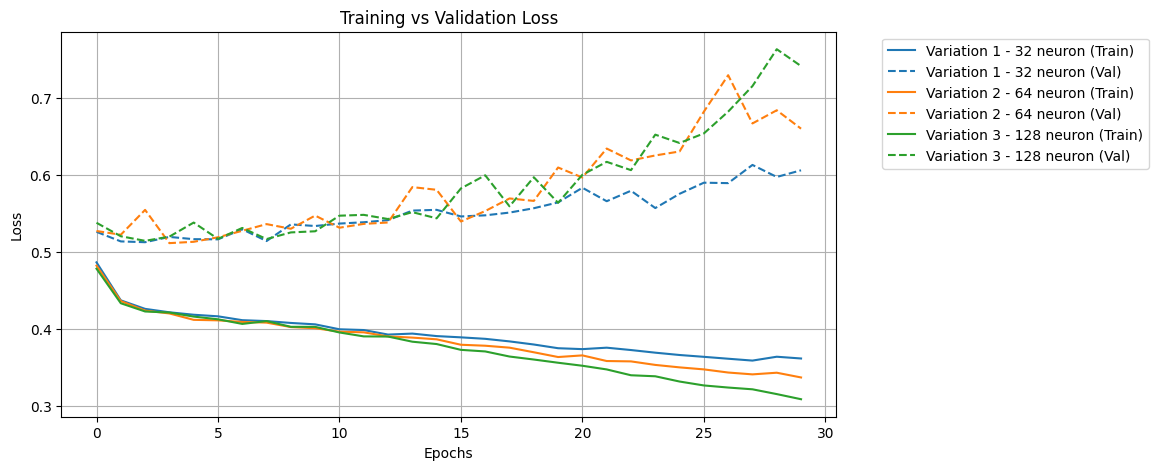

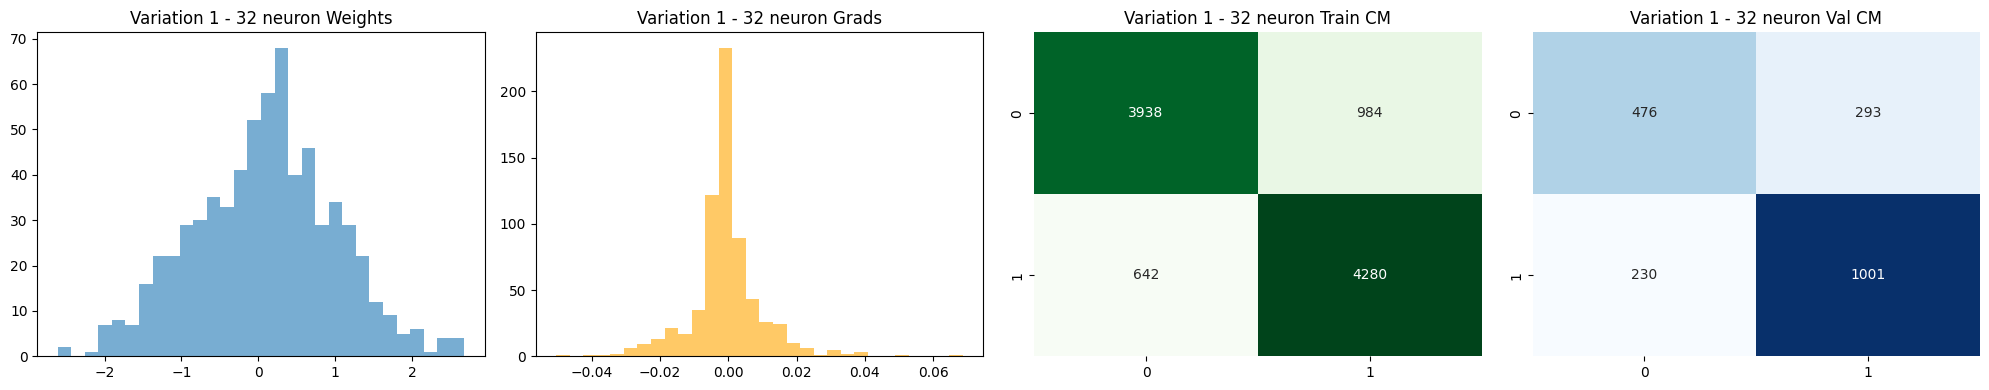


EXPERIMENT: Variation 1 - 32 neuron
ACCURACY | Train: 0.8348 | Validation: 0.7385

Validation Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.62      0.65       769
           1       0.77      0.81      0.79      1231

    accuracy                           0.74      2000
   macro avg       0.72      0.72      0.72      2000
weighted avg       0.74      0.74      0.74      2000



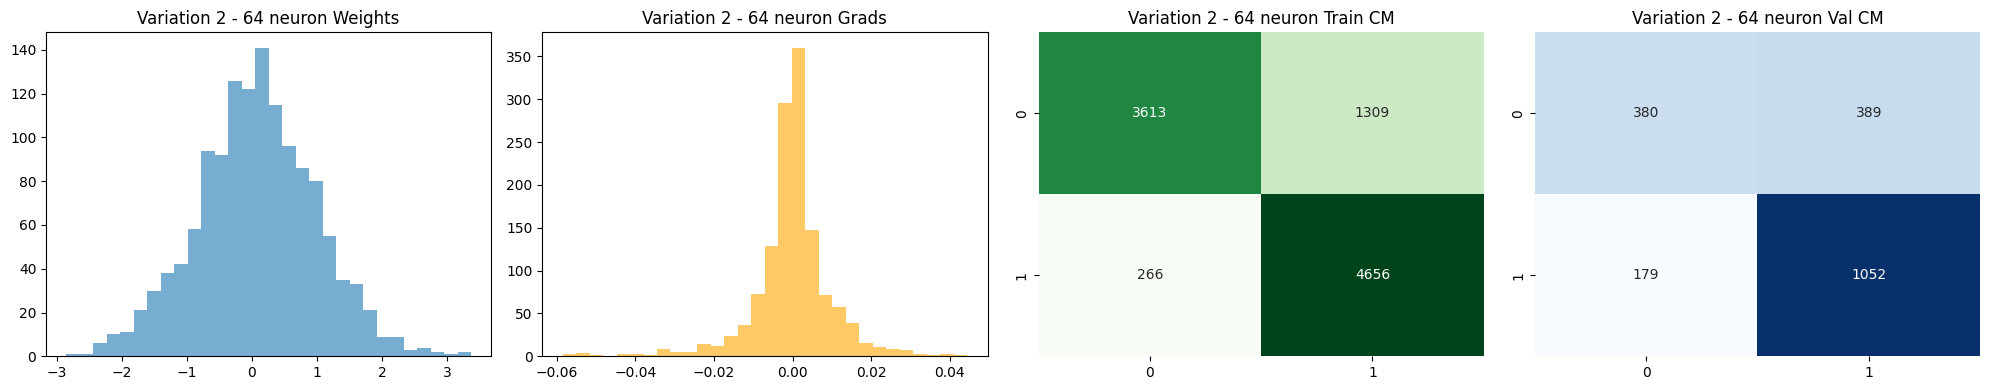


EXPERIMENT: Variation 2 - 64 neuron
ACCURACY | Train: 0.8400 | Validation: 0.7160

Validation Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.49      0.57       769
           1       0.73      0.85      0.79      1231

    accuracy                           0.72      2000
   macro avg       0.70      0.67      0.68      2000
weighted avg       0.71      0.72      0.70      2000



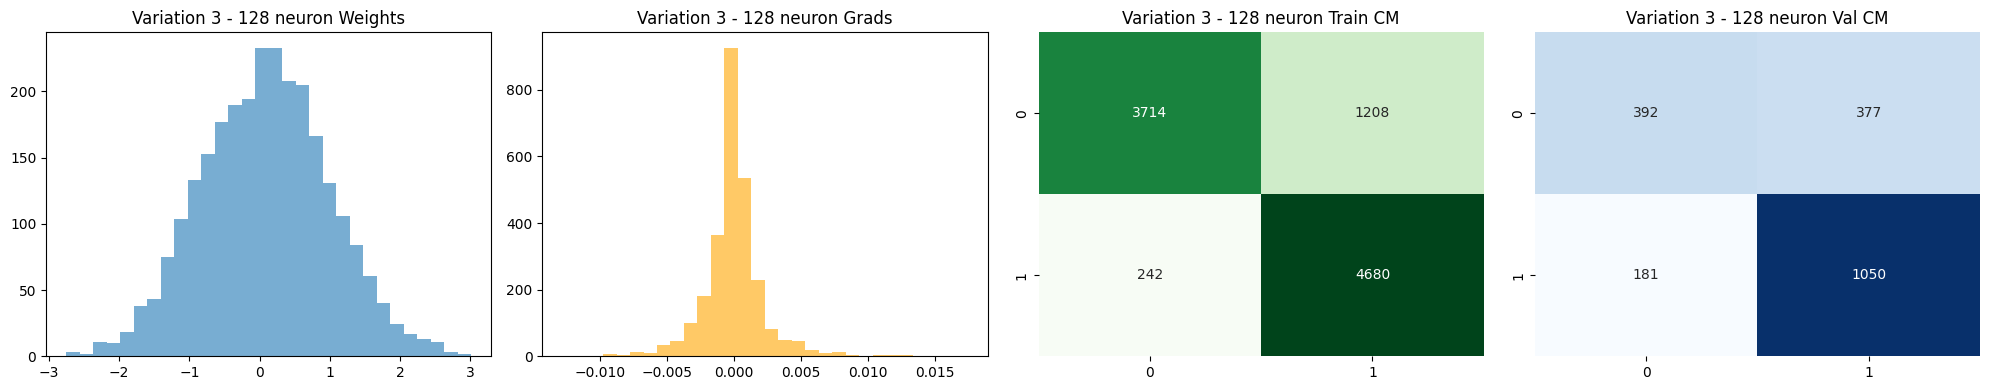


EXPERIMENT: Variation 3 - 128 neuron
ACCURACY | Train: 0.8527 | Validation: 0.7210

Validation Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.51      0.58       769
           1       0.74      0.85      0.79      1231

    accuracy                           0.72      2000
   macro avg       0.71      0.68      0.69      2000
weighted avg       0.72      0.72      0.71      2000



In [56]:
# Uji Width

results = {}

variation = ["Variation 1 - 32 neuron", "Variation 2 - 64 neuron", "Variation 3 - 128 neuron"]
neuron = [32,64,128]

for i in range(len(variation)):
    print(f"Training {variation[i]}")
    m = FFNN(loss='bce')
    m.add(Layer(21, neuron[i], activation='relu', init_method='he'))
    m.add(Layer(neuron[i], 16, activation='relu', init_method='he'))
    m.add(Layer(16, 1, activation='sigmoid', init_method='xavier'))

    h = m.fit(X_train_classification, y_train_classification.reshape(-1, 1), 
              epochs=30, batch_size=32, verbose=0, 
              validation_data=(X_test_classification, y_test_classification.reshape(-1, 1)))

    results[variation[i]] = {
        'model': m, 'history': h,
        'y_train_true': y_train_classification, 'y_train_pred': m.predict(X_train_classification),
        'y_val_true': y_test_classification, 'y_val_pred': m.predict(X_test_classification)
    }
    print(f"Done: {variation[i]}")

study_results(results, lyr=0, is_cls=True)


Training Variation 1 - 2 HL
Done: Variation 1 - 2 HL
Training Variation 2 - 3 HL
Done: Variation 2 - 3 HL
Training Variation 3 - 4 HL
Done: Variation 3 - 4 HL


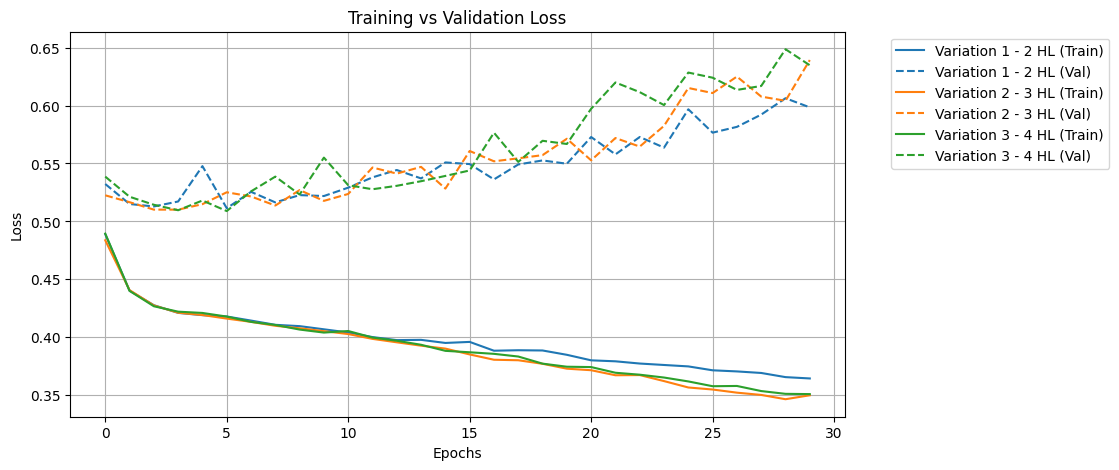

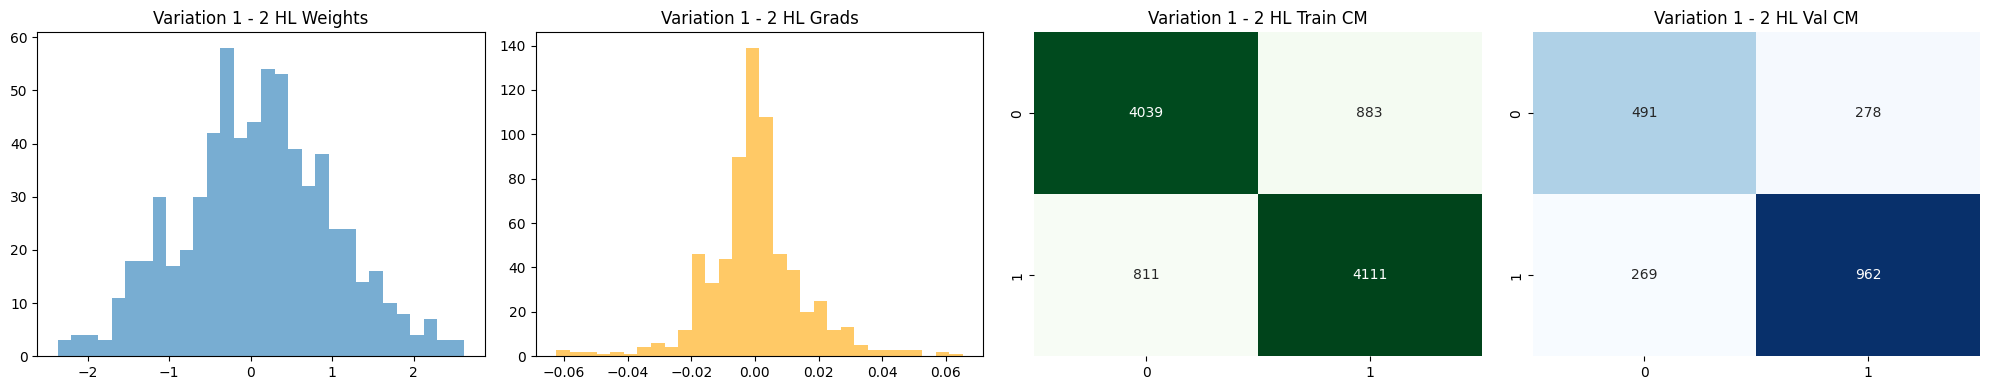


EXPERIMENT: Variation 1 - 2 HL
ACCURACY | Train: 0.8279 | Validation: 0.7265

Validation Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.64      0.64       769
           1       0.78      0.78      0.78      1231

    accuracy                           0.73      2000
   macro avg       0.71      0.71      0.71      2000
weighted avg       0.73      0.73      0.73      2000



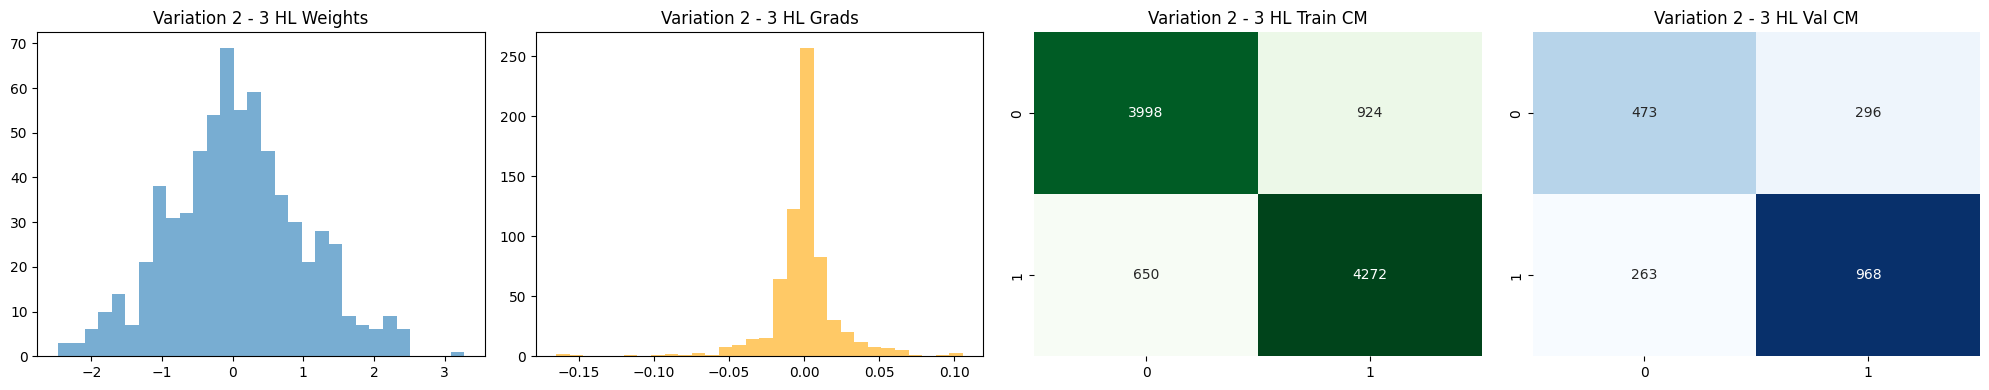


EXPERIMENT: Variation 2 - 3 HL
ACCURACY | Train: 0.8401 | Validation: 0.7205

Validation Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.62      0.63       769
           1       0.77      0.79      0.78      1231

    accuracy                           0.72      2000
   macro avg       0.70      0.70      0.70      2000
weighted avg       0.72      0.72      0.72      2000



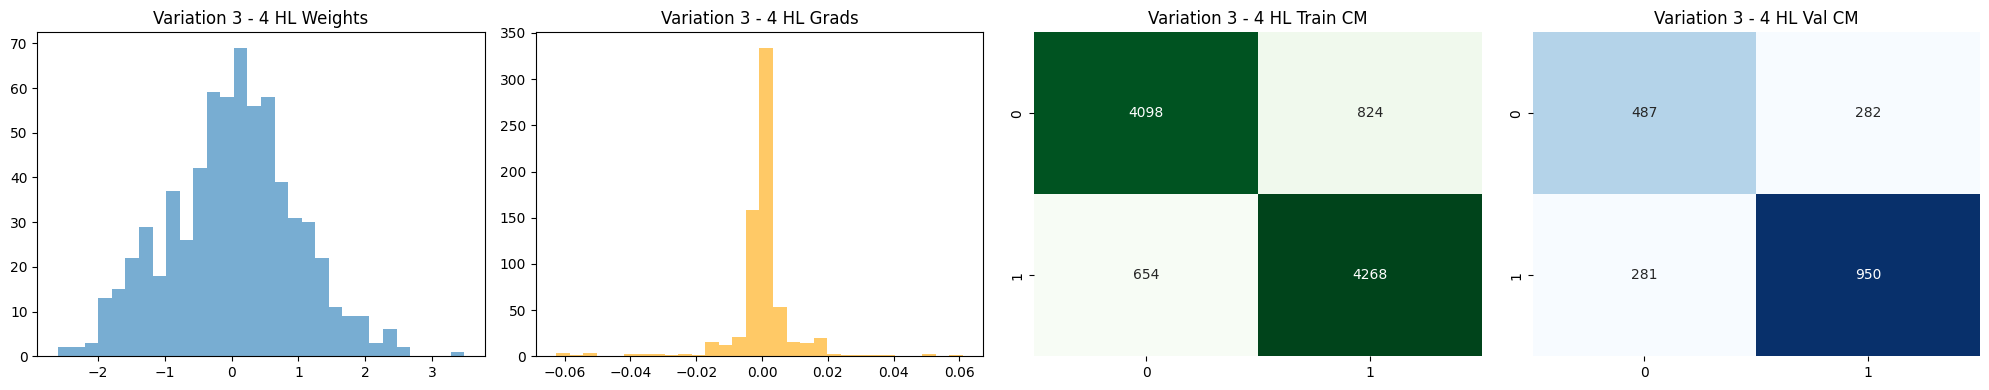


EXPERIMENT: Variation 3 - 4 HL
ACCURACY | Train: 0.8499 | Validation: 0.7185

Validation Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.63      0.63       769
           1       0.77      0.77      0.77      1231

    accuracy                           0.72      2000
   macro avg       0.70      0.70      0.70      2000
weighted avg       0.72      0.72      0.72      2000



In [57]:
# Uji Depth

results = {}

variation = ["Variation 1 - 2 HL", "Variation 2 - 3 HL", "Variation 3 - 4 HL"]
layer = [0,1,2]

for i in range(len(variation)):
    print(f"Training {variation[i]}")
    m = FFNN(loss='bce')
    m.add(Layer(21, 32, activation='relu', init_method='he'))
    for j in range(layer[i]):
        m.add(Layer(32, 32, activation='relu', init_method='he'))    
    m.add(Layer(32, 16, activation='relu', init_method='he'))
    m.add(Layer(16, 1, activation='sigmoid', init_method='xavier'))

    h = m.fit(X_train_classification, y_train_classification.reshape(-1, 1), 
              epochs=30, batch_size=32, verbose=0, 
              validation_data=(X_test_classification, y_test_classification.reshape(-1, 1)))

    results[variation[i]] = {
        'model': m, 'history': h,
        'y_train_true': y_train_classification, 'y_train_pred': m.predict(X_train_classification),
        'y_val_true': y_test_classification, 'y_val_pred': m.predict(X_test_classification)
    }
    print(f"Done: {variation[i]}")

study_results(results, lyr=0, is_cls=True)


## Experiment Fungsi Aktivasi

### Calssification

##### SKLearn

In [58]:
# activations test
sklearn_activations = ['identity', 'relu', 'logistic', 'tanh']
sklearn_models = {}

for activation in sklearn_activations:
    mlp = MLPClassifier(
        hidden_layer_sizes=(32, 16, 8),
        activation=activation,   
        solver='sgd',
        learning_rate_init=0.01,
        max_iter=50,
        batch_size=32,
        random_state=42
    )
    mlp.fit(X_train_classification, y_train_classification)
    sklearn_models[activation] = mlp
    print(f"Finish model {activation}")

Finish model identity


/home/astha/.local/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Finish model relu


/home/astha/.local/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Finish model logistic
Finish model tanh


/home/astha/.local/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


In [59]:
# Evaluation
for activation, model in sklearn_models.items():
    y_pred = model.predict(X_test_classification)
    acc = accuracy_score(y_test_classification, y_pred)
    print(f"Accuracy for {activation}: {acc:.4f}")
    print(f"Classification Report for {activation}:\n{classification_report(y_test_classification, y_pred)}")
    print(f"Confusion Matrix for {activation}:\n{confusion_matrix(y_test_classification, y_pred)}\n")
    

Accuracy for identity: 0.7360
Classification Report for identity:
              precision    recall  f1-score   support

           0       0.65      0.69      0.67       769
           1       0.80      0.77      0.78      1231

    accuracy                           0.74      2000
   macro avg       0.72      0.73      0.72      2000
weighted avg       0.74      0.74      0.74      2000

Confusion Matrix for identity:
[[527 242]
 [286 945]]

Accuracy for relu: 0.7180
Classification Report for relu:
              precision    recall  f1-score   support

           0       0.66      0.55      0.60       769
           1       0.74      0.83      0.78      1231

    accuracy                           0.72      2000
   macro avg       0.70      0.69      0.69      2000
weighted avg       0.71      0.72      0.71      2000

Confusion Matrix for relu:
[[ 420  349]
 [ 215 1016]]

Accuracy for logistic: 0.7445
Classification Report for logistic:
              precision    recall  f1-score   

##### Custom FFNN

Training with linear...
Done: linear
Training with relu...
Done: relu
Training with tanh...
Done: tanh
Training with leaky_relu...
Done: leaky_relu
Training with elu...
Done: elu


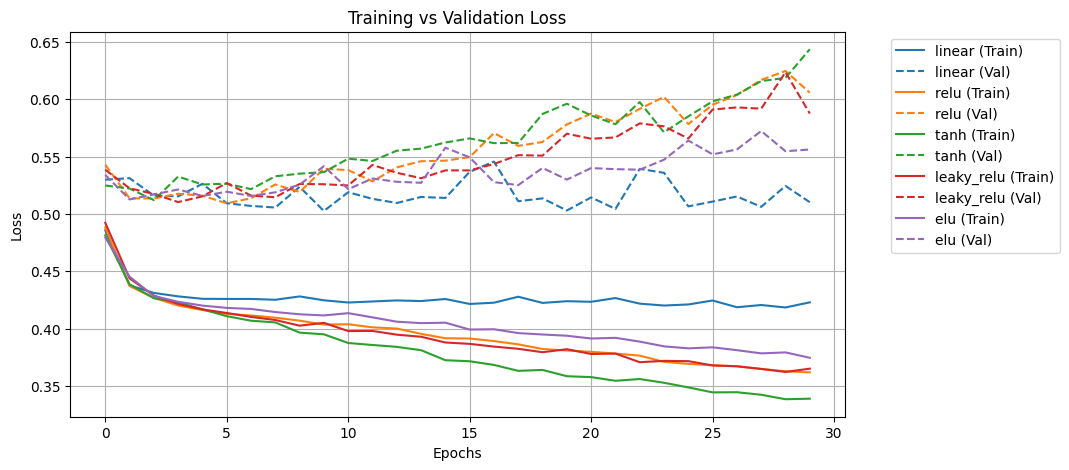

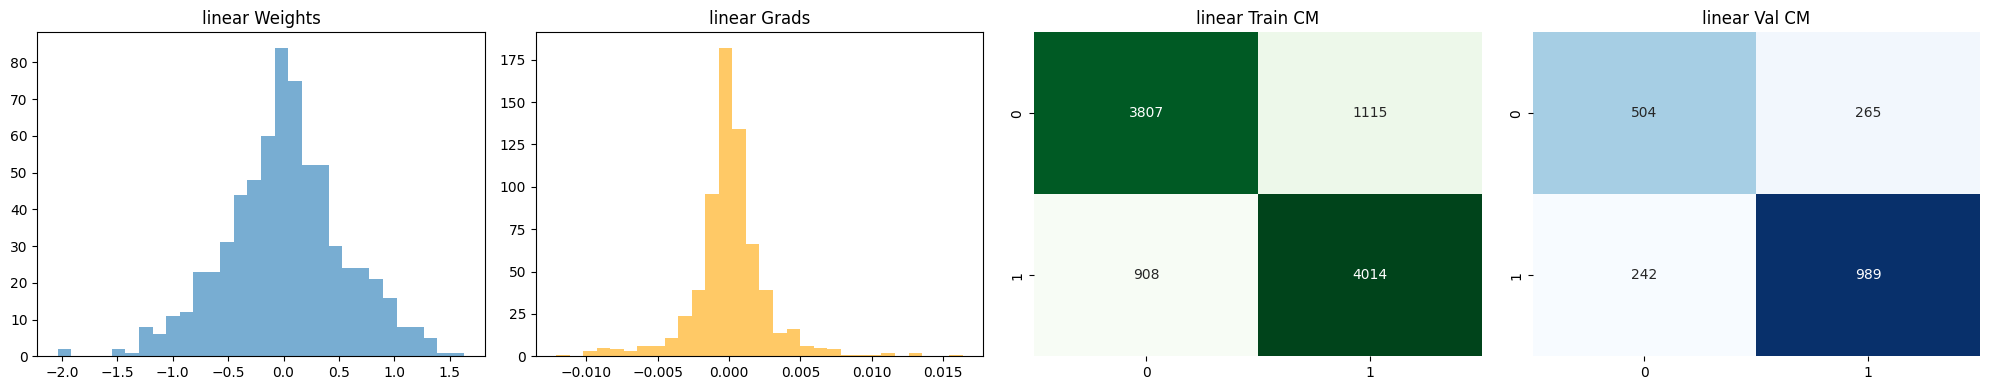


EXPERIMENT: linear
ACCURACY | Train: 0.7945 | Validation: 0.7465

Validation Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.66      0.67       769
           1       0.79      0.80      0.80      1231

    accuracy                           0.75      2000
   macro avg       0.73      0.73      0.73      2000
weighted avg       0.75      0.75      0.75      2000



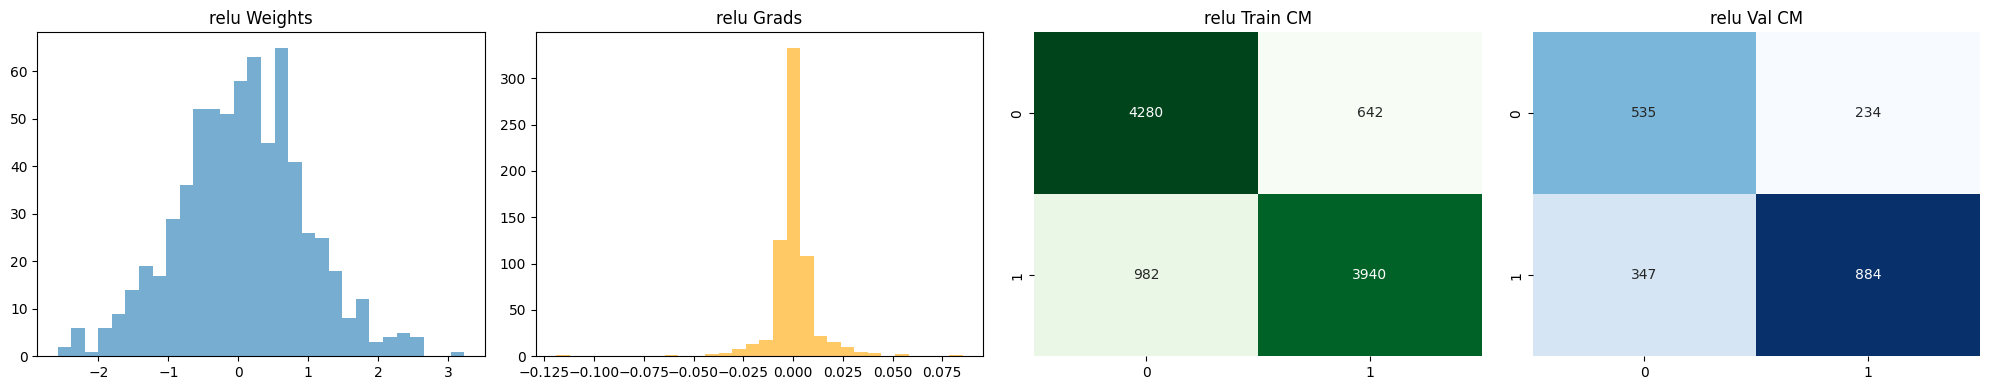


EXPERIMENT: relu
ACCURACY | Train: 0.8350 | Validation: 0.7095

Validation Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.70      0.65       769
           1       0.79      0.72      0.75      1231

    accuracy                           0.71      2000
   macro avg       0.70      0.71      0.70      2000
weighted avg       0.72      0.71      0.71      2000



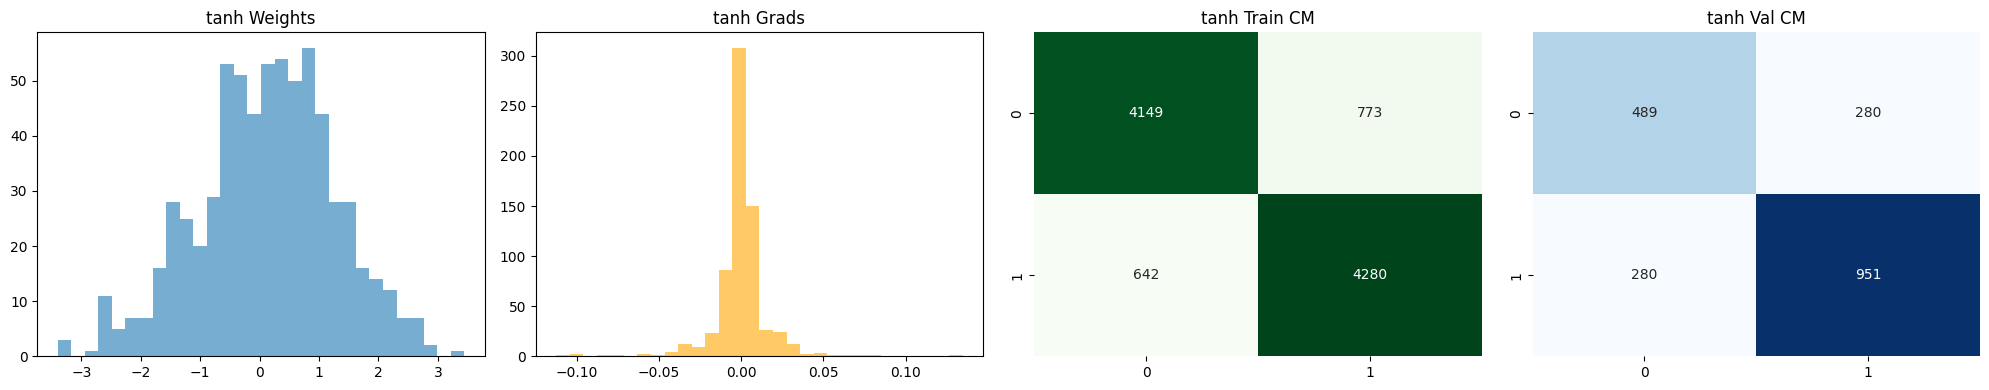


EXPERIMENT: tanh
ACCURACY | Train: 0.8563 | Validation: 0.7200

Validation Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.64      0.64       769
           1       0.77      0.77      0.77      1231

    accuracy                           0.72      2000
   macro avg       0.70      0.70      0.70      2000
weighted avg       0.72      0.72      0.72      2000



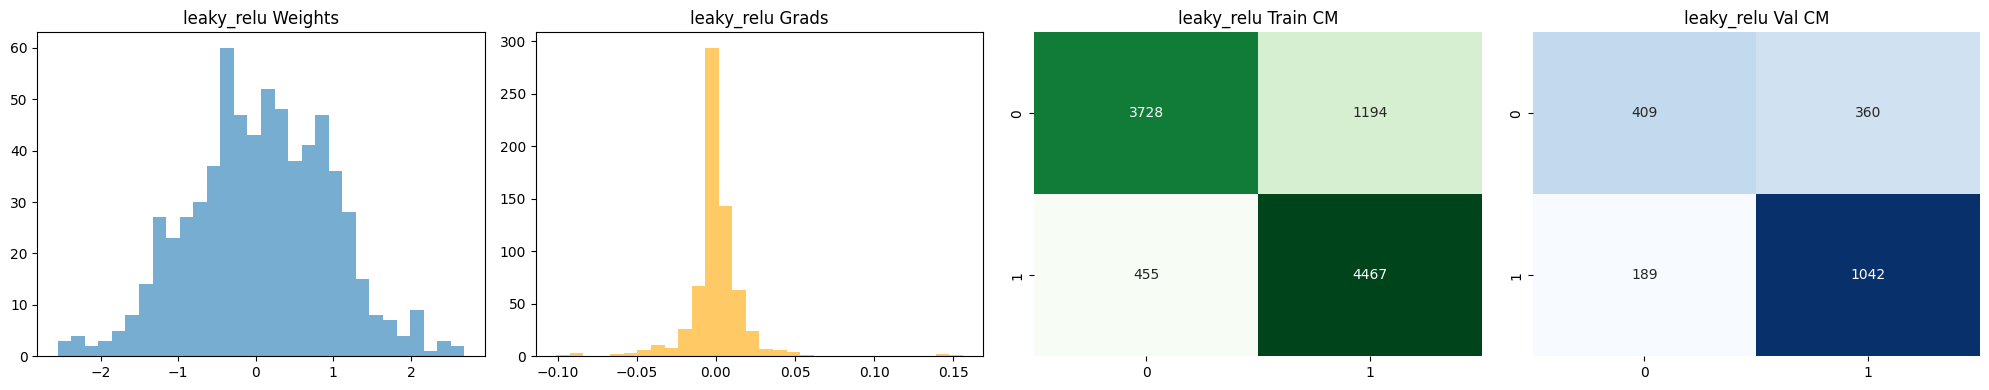


EXPERIMENT: leaky_relu
ACCURACY | Train: 0.8325 | Validation: 0.7255

Validation Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.53      0.60       769
           1       0.74      0.85      0.79      1231

    accuracy                           0.73      2000
   macro avg       0.71      0.69      0.69      2000
weighted avg       0.72      0.73      0.72      2000



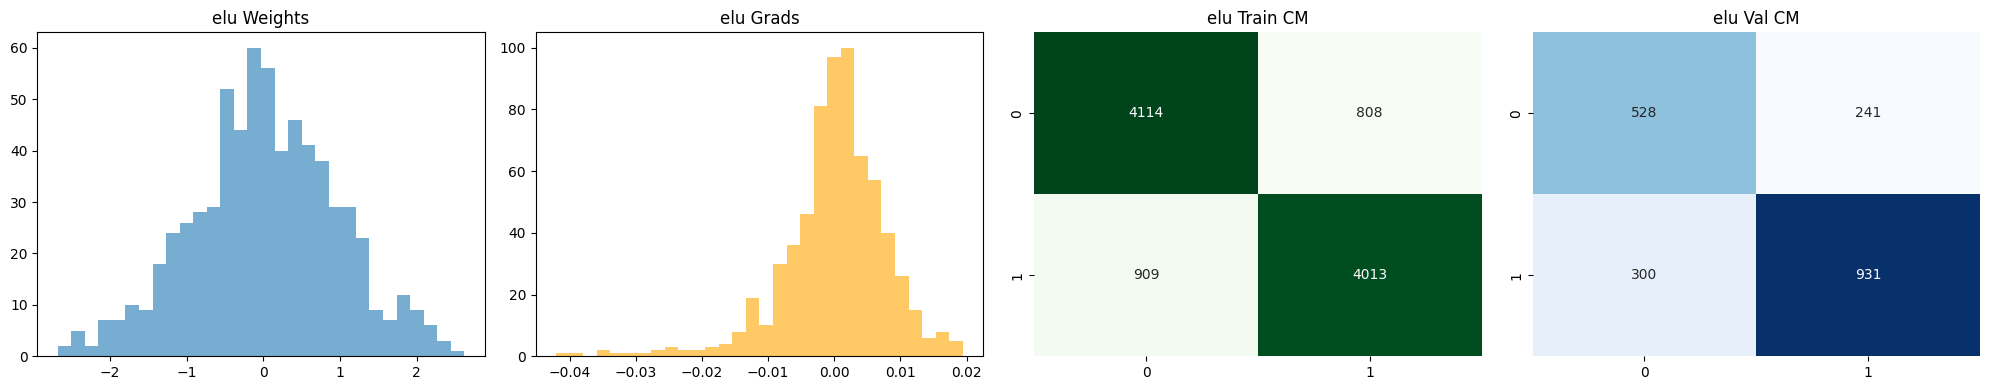


EXPERIMENT: elu
ACCURACY | Train: 0.8256 | Validation: 0.7295

Validation Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.69      0.66       769
           1       0.79      0.76      0.77      1231

    accuracy                           0.73      2000
   macro avg       0.72      0.72      0.72      2000
weighted avg       0.73      0.73      0.73      2000



In [60]:
activations = ['linear', 'relu', 'tanh', 'leaky_relu', 'elu']
results = {}

for act in activations:
    print(f"Training with {act}...")
    m = FFNN(loss='bce')
    m.add(Layer(21, 32, activation=act, init_method='he'))
    m.add(Layer(32, 16, activation='relu', init_method='he'))
    m.add(Layer(16, 1, activation='sigmoid', init_method='xavier'))

   
    h = m.fit(X_train_classification, y_train_classification.reshape(-1, 1), 
              epochs=30, batch_size=32, verbose=0, 
              validation_data=(X_test_classification, y_test_classification.reshape(-1, 1)))
    
    results[act] = {
        'model': m, 'history': h,
        'y_train_true': y_train_classification, 'y_train_pred': m.predict(X_train_classification),
        'y_val_true': y_test_classification, 'y_val_pred': m.predict(X_test_classification)
    }
    print(f"Done: {act}")

study_results(results, lyr=0, is_cls=True)

## Eksperimen Regularisasi

Dalam eksperimen ini, kita membandingkan tiga model:
1. **Tanpa Regularisasi**
2. **Regularisasi L1** (memacu bobot menjadi nol/sparse)
3. **Regularisasi L2** (memacu bobot menjadi kecil/weight decay)

Training with Regularization: None...
Done: None
Training with Regularization: L1...
Done: L1
Training with Regularization: L2...
Done: L2


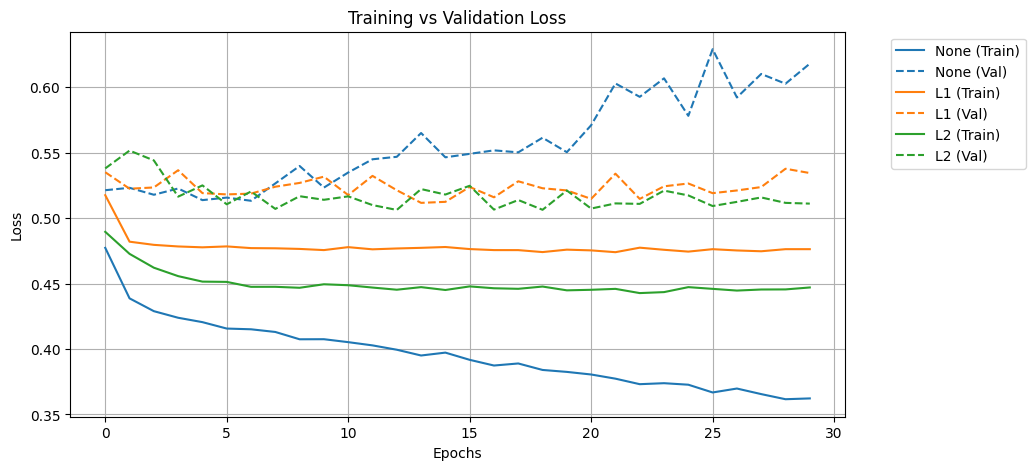

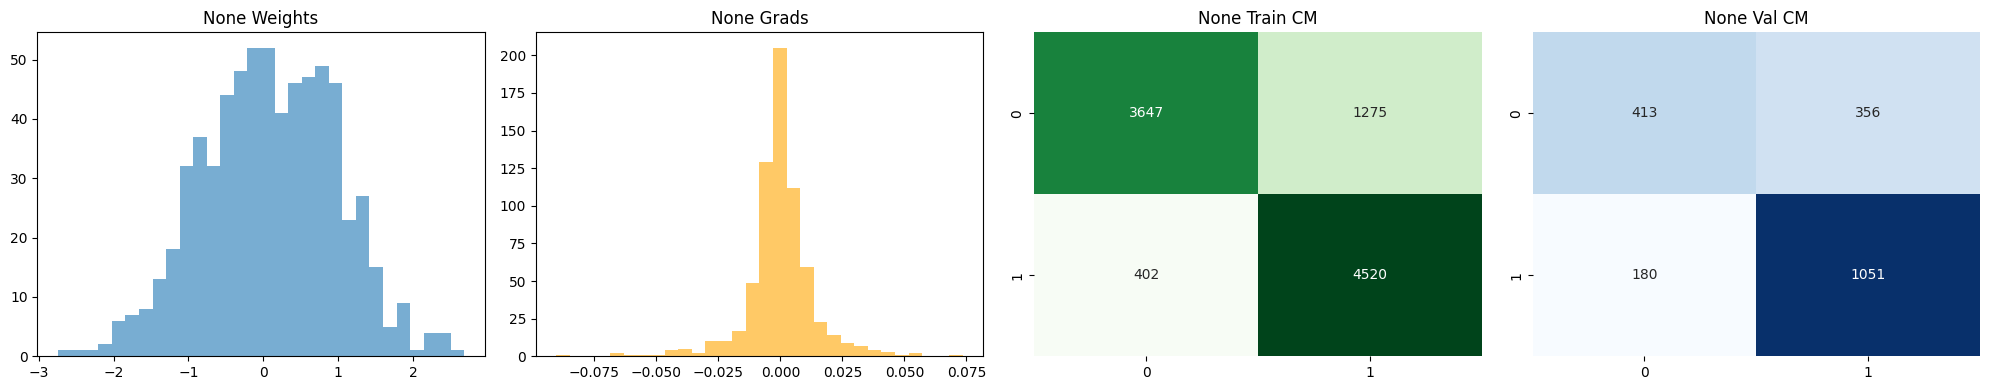


EXPERIMENT: None
ACCURACY | Train: 0.8296 | Validation: 0.7320

Validation Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.54      0.61       769
           1       0.75      0.85      0.80      1231

    accuracy                           0.73      2000
   macro avg       0.72      0.70      0.70      2000
weighted avg       0.73      0.73      0.72      2000



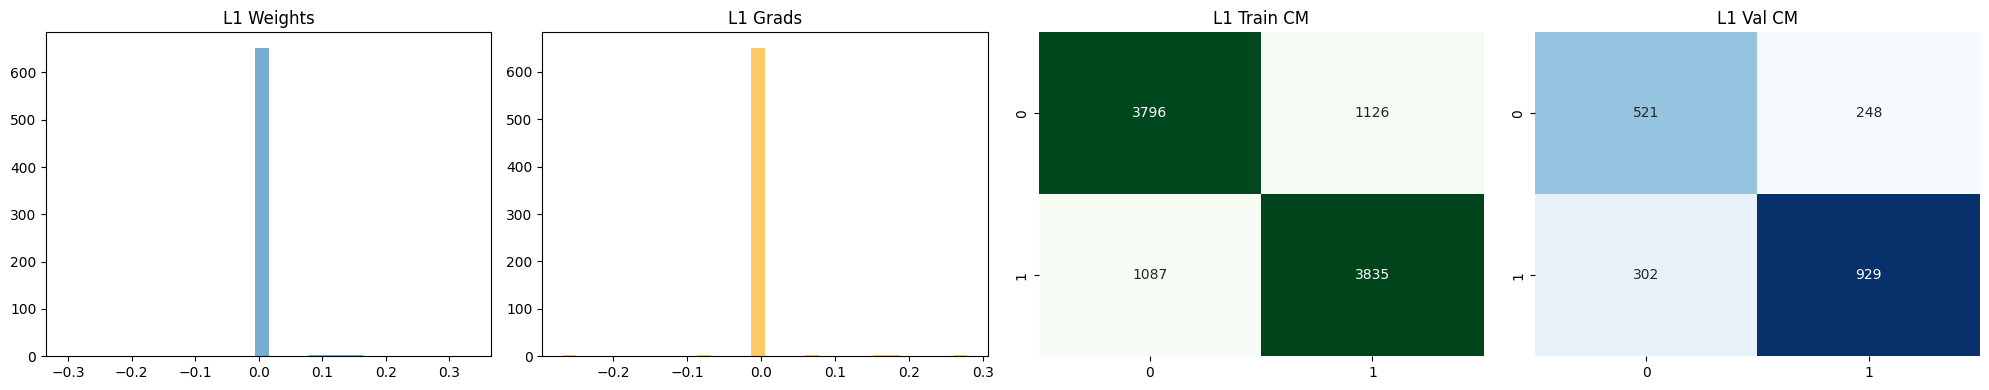


EXPERIMENT: L1
ACCURACY | Train: 0.7752 | Validation: 0.7250

Validation Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.68      0.65       769
           1       0.79      0.75      0.77      1231

    accuracy                           0.72      2000
   macro avg       0.71      0.72      0.71      2000
weighted avg       0.73      0.72      0.73      2000



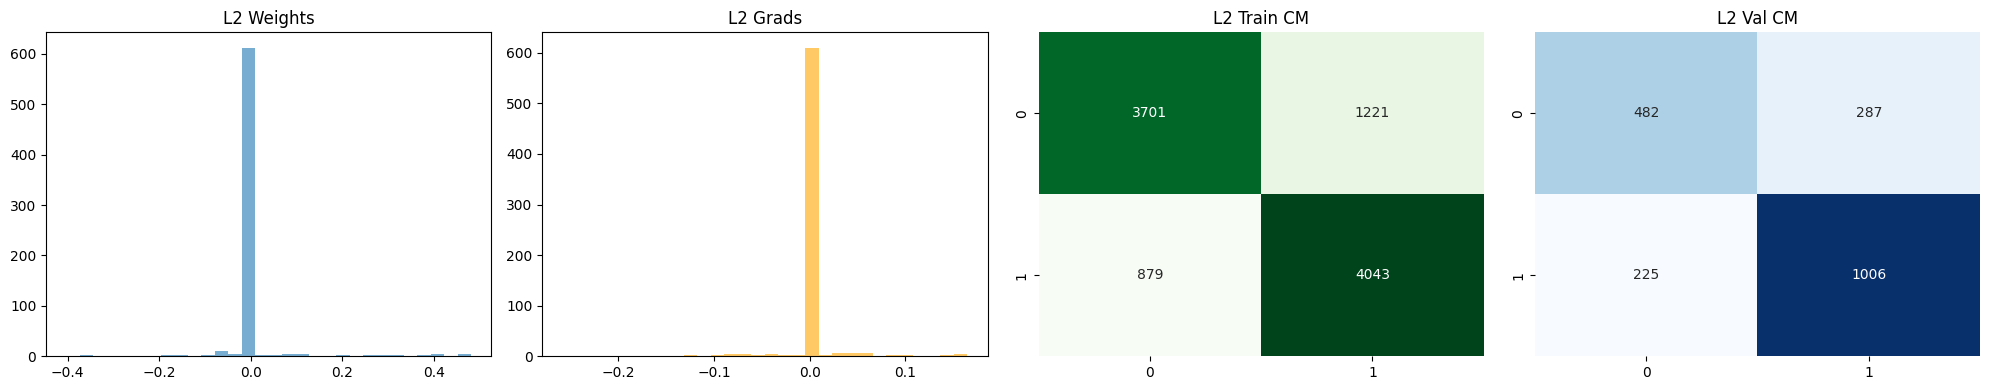


EXPERIMENT: L2
ACCURACY | Train: 0.7867 | Validation: 0.7440

Validation Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.63      0.65       769
           1       0.78      0.82      0.80      1231

    accuracy                           0.74      2000
   macro avg       0.73      0.72      0.73      2000
weighted avg       0.74      0.74      0.74      2000



In [61]:
variations = [
    ('None', 0.0, 0.0),
    ('L1', 0.01, 0.0),
    ('L2', 0.0, 0.01)
]

results_reg = {}

for label, l1_val, l2_val in variations:
    print(f"Training with Regularization: {label}...")
    m = FFNN(loss='bce')
    # Menggunakan base arsitektur yang sama (3 layer)
    m.add(Layer(21, 32, activation='relu', init_method='he'))
    m.add(Layer(32, 16, activation='relu', init_method='he'))
    m.add(Layer(16, 1, activation='sigmoid', init_method='xavier'))

    h = m.fit(X_train_classification, y_train_classification.reshape(-1, 1), 
              epochs=30, batch_size=32, verbose=0, 
              l1=l1_val, l2=l2_val,
              validation_data=(X_test_classification, y_test_classification.reshape(-1, 1)))
    
    results_reg[label] = {
        'model': m, 'history': h,
        'y_train_true': y_train_classification, 'y_train_pred': m.predict(X_train_classification),
        'y_val_true': y_test_classification, 'y_val_pred': m.predict(X_test_classification)
    }
    print(f"Done: {label}")

# Visualisasi hasil perbandingan
study_results(results_reg, lyr=0, is_cls=True)

## Experiment Learning Rate

Training 0.01
Done: 0.01
Training 0.005
Done: 0.005
Training 0.001
Done: 0.001


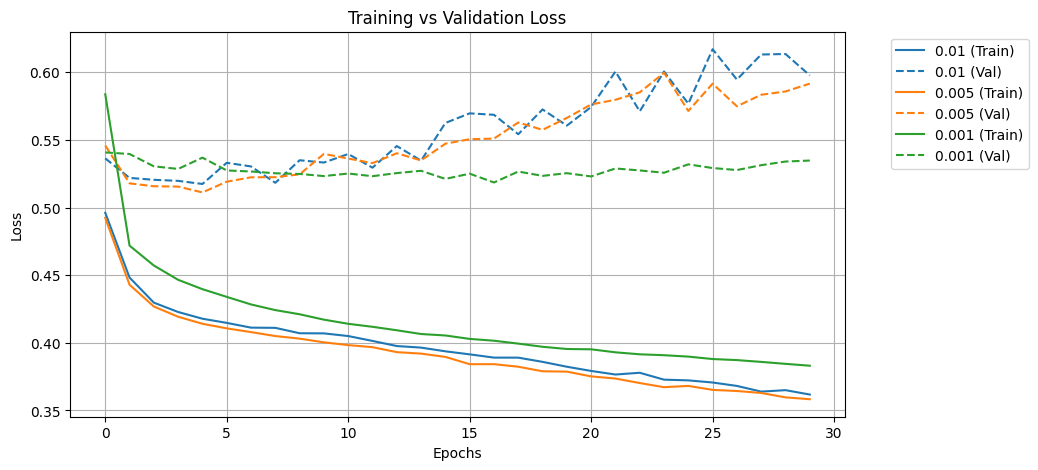

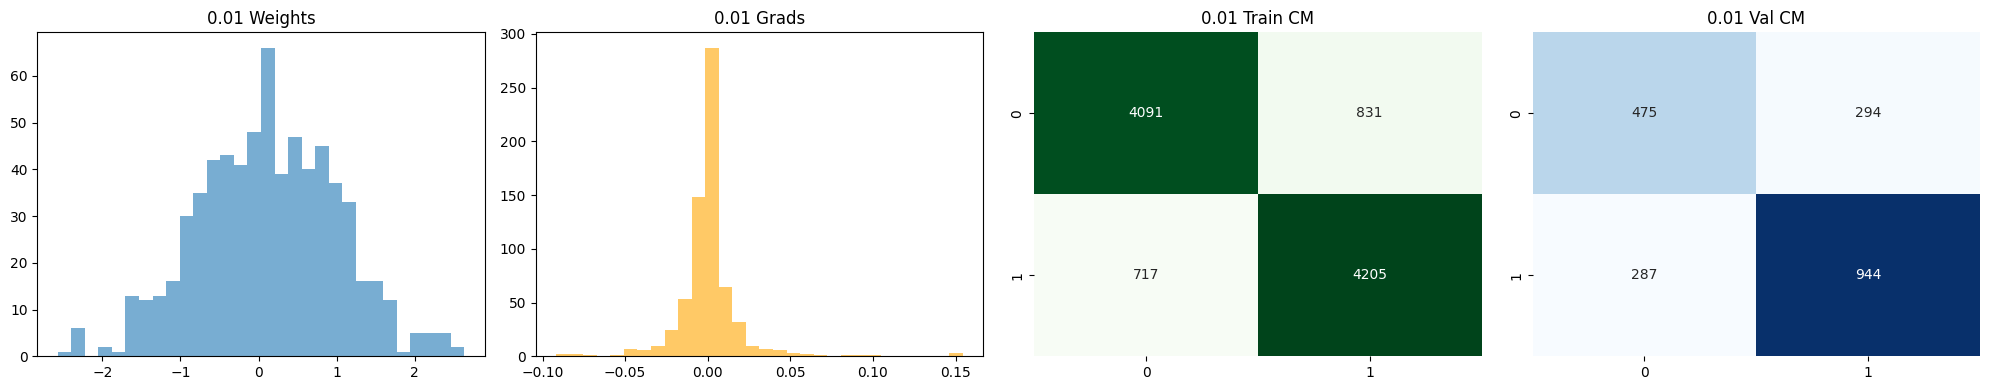


EXPERIMENT: 0.01
ACCURACY | Train: 0.8427 | Validation: 0.7095

Validation Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.62      0.62       769
           1       0.76      0.77      0.76      1231

    accuracy                           0.71      2000
   macro avg       0.69      0.69      0.69      2000
weighted avg       0.71      0.71      0.71      2000



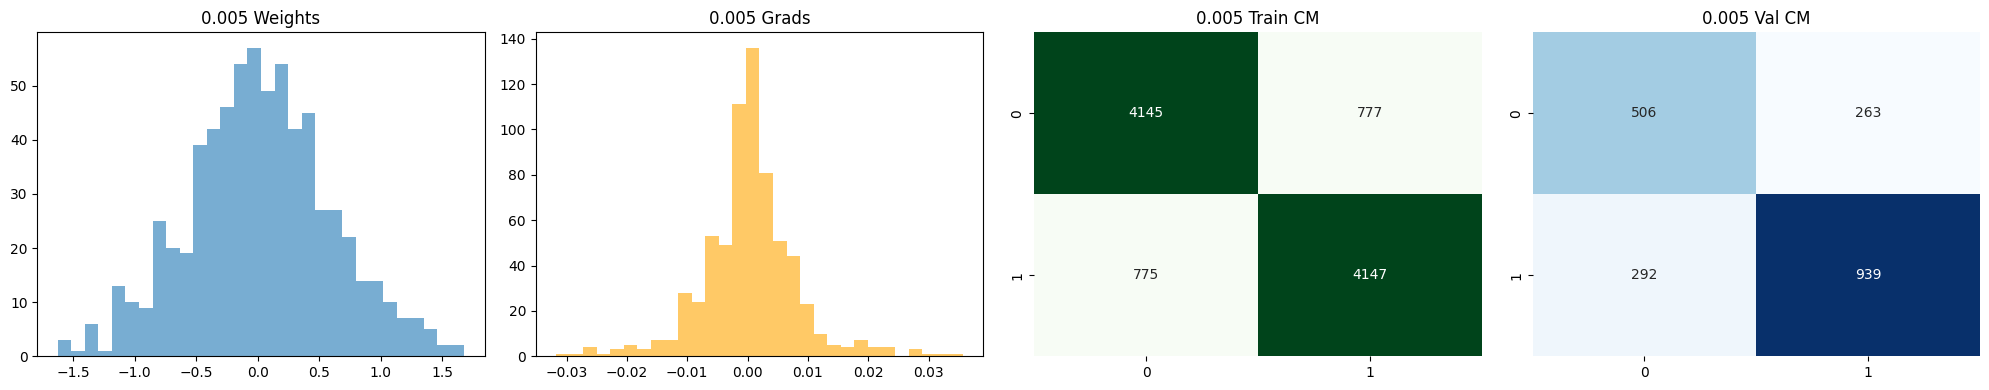


EXPERIMENT: 0.005
ACCURACY | Train: 0.8423 | Validation: 0.7225

Validation Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.66      0.65       769
           1       0.78      0.76      0.77      1231

    accuracy                           0.72      2000
   macro avg       0.71      0.71      0.71      2000
weighted avg       0.72      0.72      0.72      2000



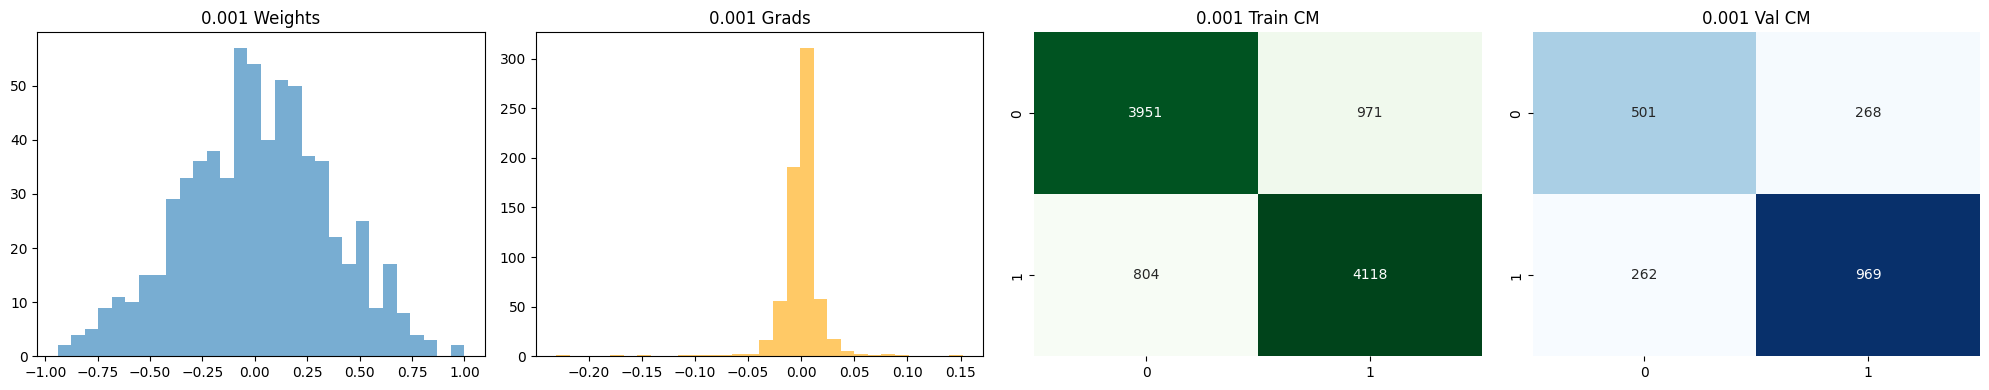


EXPERIMENT: 0.001
ACCURACY | Train: 0.8197 | Validation: 0.7350

Validation Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.65      0.65       769
           1       0.78      0.79      0.79      1231

    accuracy                           0.73      2000
   macro avg       0.72      0.72      0.72      2000
weighted avg       0.73      0.73      0.73      2000



In [62]:
# Uji Width

results = {}

variation = [0.01, 0.005, 0.001]

for i in range(len(variation)):
    print(f"Training {variation[i]}")
    m = FFNN(loss='bce')
    m.add(Layer(21, 32, activation='relu', init_method='he'))
    m.add(Layer(32, 16, activation='relu', init_method='he'))
    m.add(Layer(16, 1, activation='sigmoid', init_method='xavier'))

    h = m.fit(X_train_classification, y_train_classification.reshape(-1, 1), 
              epochs=30, batch_size=32, verbose=0, learning_rate=variation[i],
              validation_data=(X_test_classification, y_test_classification.reshape(-1, 1)))

    results[variation[i]] = {
        'model': m, 'history': h,
        'y_train_true': y_train_classification, 'y_train_pred': m.predict(X_train_classification),
        'y_val_true': y_test_classification, 'y_val_pred': m.predict(X_test_classification)
    }
    print(f"Done: {variation[i]}")

study_results(results, lyr=0, is_cls=True)


## Experiment Regularisasi

Training no reguralization
Done: no reguralization
Training l1
Done: l1
Training l2
Done: l2


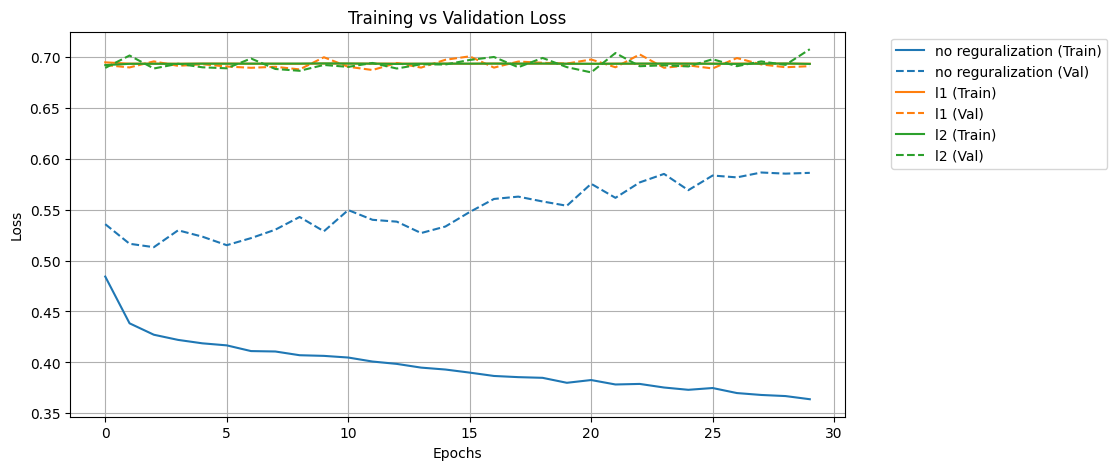

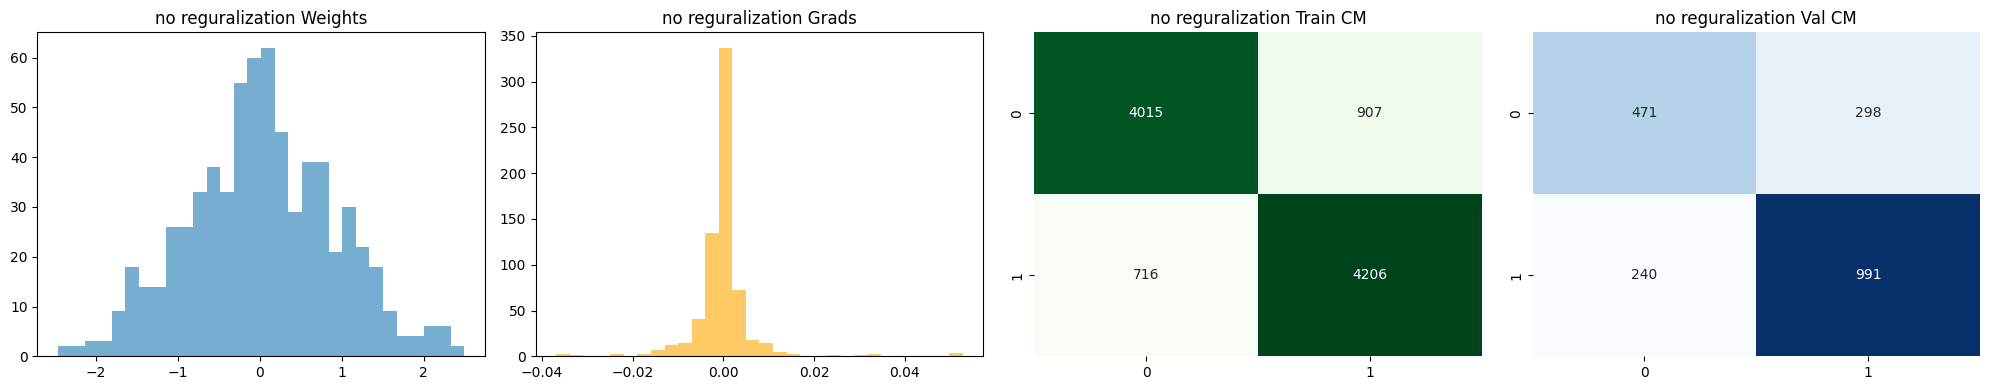


EXPERIMENT: no reguralization
ACCURACY | Train: 0.8351 | Validation: 0.7310

Validation Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.61      0.64       769
           1       0.77      0.81      0.79      1231

    accuracy                           0.73      2000
   macro avg       0.72      0.71      0.71      2000
weighted avg       0.73      0.73      0.73      2000



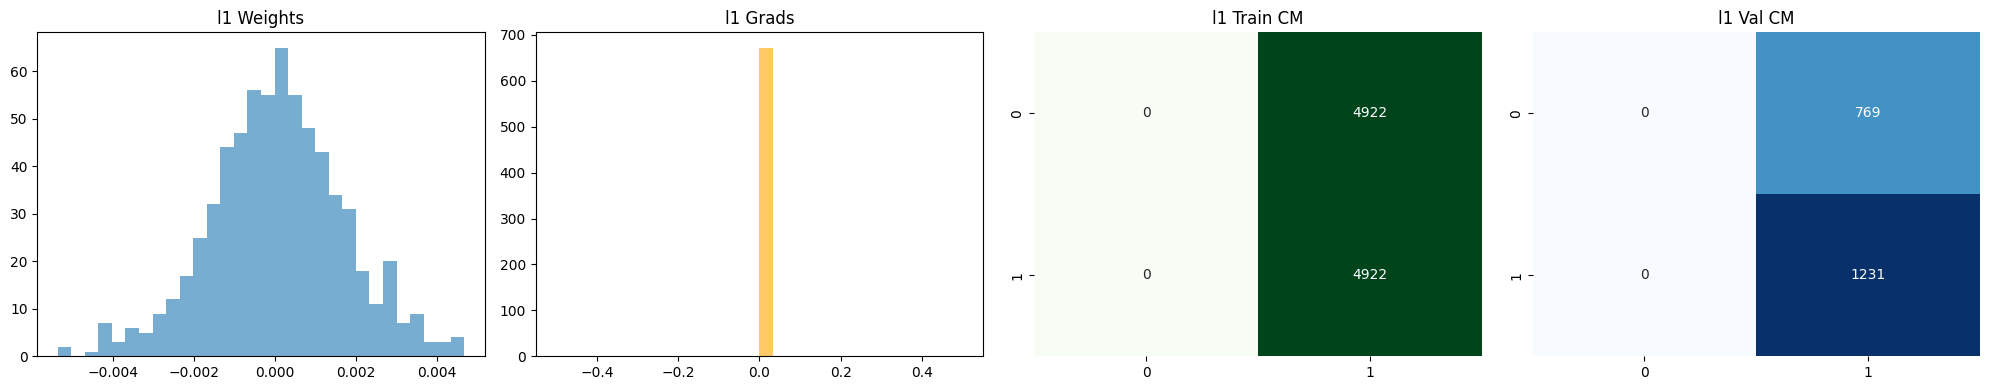


EXPERIMENT: l1
ACCURACY | Train: 0.5000 | Validation: 0.6155

Validation Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       769
           1       0.62      1.00      0.76      1231

    accuracy                           0.62      2000
   macro avg       0.31      0.50      0.38      2000
weighted avg       0.38      0.62      0.47      2000



/home/astha/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/astha/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/astha/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


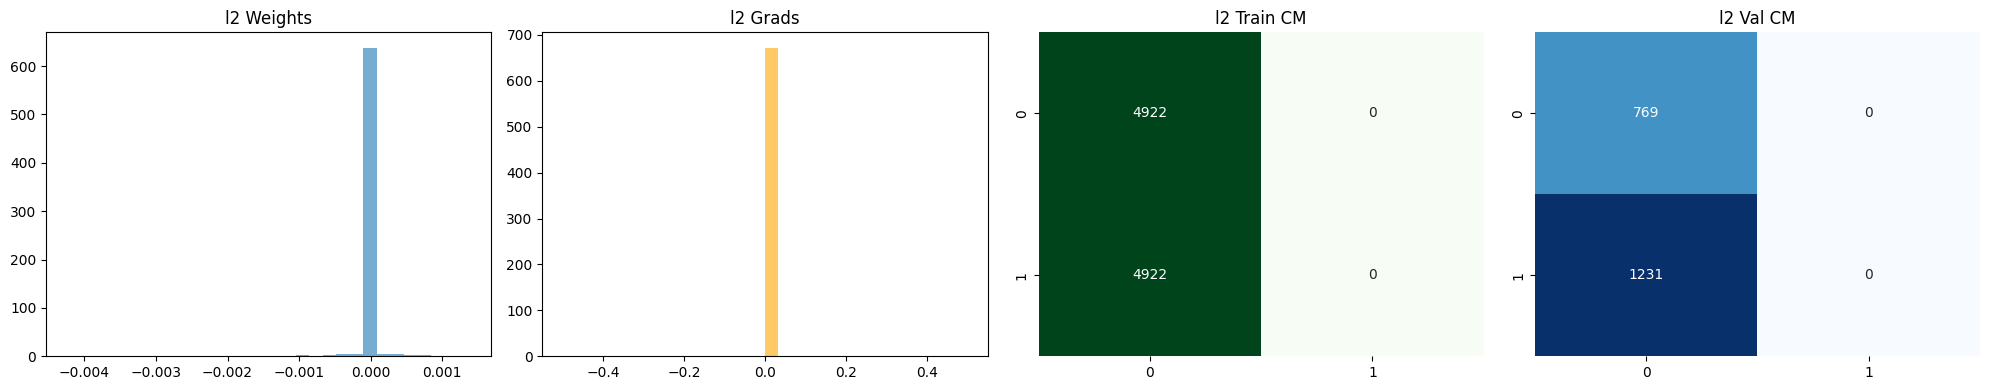


EXPERIMENT: l2
ACCURACY | Train: 0.5000 | Validation: 0.3845

Validation Classification Report:
              precision    recall  f1-score   support

           0       0.38      1.00      0.56       769
           1       0.00      0.00      0.00      1231

    accuracy                           0.38      2000
   macro avg       0.19      0.50      0.28      2000
weighted avg       0.15      0.38      0.21      2000



/home/astha/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/astha/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/astha/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [63]:
# Uji Regularisasi

results = {}

variation = [[0,0], [0.1, 0], [0, 0.1]]
titles = ['no reguralization', 'l1', 'l2']

for i in range(len(variation)):
    print(f"Training {titles[i]}")
    m = FFNN(loss='bce')
    m.add(Layer(21, 32, activation='relu', init_method='he'))
    m.add(Layer(32, 16, activation='relu', init_method='he'))
    m.add(Layer(16, 1, activation='sigmoid', init_method='xavier'))

    h = m.fit(X_train_classification, y_train_classification.reshape(-1, 1), 
              epochs=30, batch_size=32, verbose=0, l1=variation[i][0], l2=variation[i][1],
              validation_data=(X_test_classification, y_test_classification.reshape(-1, 1)))

    results[titles[i]] = {
        'model': m, 'history': h,
        'y_train_true': y_train_classification, 'y_train_pred': m.predict(X_train_classification),
        'y_val_true': y_test_classification, 'y_val_pred': m.predict(X_test_classification)
    }
    print(f"Done: {titles[i]}")

study_results(results, lyr=0, is_cls=True)


## Additional Test

### Regression Model

In [64]:
from sklearn.neural_network import MLPRegressor

# activations test
sklearn_models_reg = {}

for activation in sklearn_activations:
    mlp_reg = MLPRegressor(
        hidden_layer_sizes=(32, 16),
        activation=activation,   
        solver='adam',
        learning_rate_init=0.01,
        max_iter=100,
        batch_size=32,
        random_state=42
    )
    mlp_reg.fit(X_train_regression, y_train_regression)
    sklearn_models_reg[activation] = mlp_reg
    print(f"Finish model {activation}")

from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
# evaluasi

for activation in sklearn_activations:
    y_pred = sklearn_models_reg[activation].predict(X_test_regression)
    mse = mean_squared_error(y_test_regression, y_pred)
    r2 = r2_score(y_test_regression, y_pred)
    print(f"SKLearn Regression {activation} - MSE: {mse:.4f}, R2 Score: {r2:.4f}")

/home/astha/.local/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:1645: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Finish model identity


/home/astha/.local/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:1645: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/astha/.local/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/astha/.local/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:1645: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Finish model relu


/home/astha/.local/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/astha/.local/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:1645: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Finish model logistic
Finish model tanh
SKLearn Regression identity - MSE: 2.2553, R2 Score: 0.0210
SKLearn Regression relu - MSE: 2.5995, R2 Score: -0.1285
SKLearn Regression logistic - MSE: 2.7992, R2 Score: -0.2152
SKLearn Regression tanh - MSE: 2.8653, R2 Score: -0.2439


/home/astha/.local/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
